In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

def plot_range_doppler(rd_map, range_res=None, doppler_res=None, title="Range-Doppler Map", cmap="viridis", figsize=(12, 8)):
    """
    绘制距离-多普勒图(RD图)，横轴为距离，纵轴为多普勒
    
    参数:
        rd_map (np.ndarray): 距离-多普勒图数据，形状为(多普勒单元数, 距离单元数)
        range_res (float, optional): 距离分辨率(米/单元)
        doppler_res (float, optional): 多普勒分辨率(米/秒/单元)
        title (str, optional): 图表标题
        cmap (str, optional): 颜色映射名称
        figsize (tuple, optional): 图表尺寸(宽, 高)
    
    返回:
        matplotlib.figure.Figure: 创建的图表对象
    """
    # 确保输入是NumPy数组
    rd_map = np.asarray(rd_map)
    
    # 获取矩阵尺寸
    num_doppler_bins, num_range_bins = rd_map.shape
    
    # 计算幅度(取绝对值)
    magnitude = np.abs(rd_map)
    
    # 创建图表和坐标轴
    fig, ax = plt.subplots(figsize=figsize)
    
    # 使用对数尺度显示(更好地展示动态范围)
    # 添加小偏移避免log(0)
    log_magnitude = np.log10(magnitude + 1e-9)
    
    # 创建热图 - 注意：横轴为距离，纵轴为多普勒
    im = ax.imshow(log_magnitude, 
                   aspect='auto', 
                   cmap=cmap,
                   origin='lower',
                   extent=[0, num_range_bins, 0, num_doppler_bins])
    
    # 添加颜色条
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label('Magnitude (dB)')
    
    # 设置坐标轴标签
    ax.set_xlabel('Range Bin')
    ax.set_ylabel('Doppler Bin')
    
    # 如果有分辨率信息，添加物理单位标签
    if range_res is not None:
        # 计算实际距离范围
        max_range = num_range_bins * range_res
        # 创建x轴刻度位置和标签
        x_ticks = np.linspace(0, num_range_bins, 5)
        x_labels = [f"{x * range_res:.0f}" for x in x_ticks]
        ax.set_xticks(x_ticks)
        ax.set_xticklabels(x_labels)
        ax.set_xlabel('Range (m)')
    
    if doppler_res is not None:
        # 计算实际多普勒范围
        max_doppler = num_doppler_bins * doppler_res / 2
        # 创建y轴刻度位置和标签
        y_ticks = np.linspace(0, num_doppler_bins, 5)
        y_labels = [f"{y * doppler_res - max_doppler:.0f}" for y in y_ticks]
        ax.set_yticks(y_ticks)
        ax.set_yticklabels(y_labels)
        ax.set_ylabel('Doppler Velocity (m/s)')
    
    # 添加网格
    ax.grid(True, linestyle='--', alpha=0.3)
    
    # 添加标题
    ax.set_title(title)
    
    # 添加零多普勒线
    if doppler_res is not None:
        zero_doppler_bin = num_doppler_bins // 2
        ax.axhline(y=zero_doppler_bin, color='r', linestyle='--', alpha=0.7)
        ax.text(num_range_bins * 0.05, zero_doppler_bin + 5, 
                'Zero Doppler', color='r', fontsize=10)
    
    # 添加距离刻度标记
    if range_res is not None:
        for distance in [100, 200, 300, 400, 500]:
            bin_idx = distance / range_res
            if bin_idx < num_range_bins:
                ax.axvline(x=bin_idx, color='w', linestyle=':', alpha=0.5)
                ax.text(bin_idx + 5, num_doppler_bins * 0.95, 
                        f'{distance}m', color='w', fontsize=9)
    
    plt.tight_layout()
    return fig

RD图数据形状: (128, 1200)


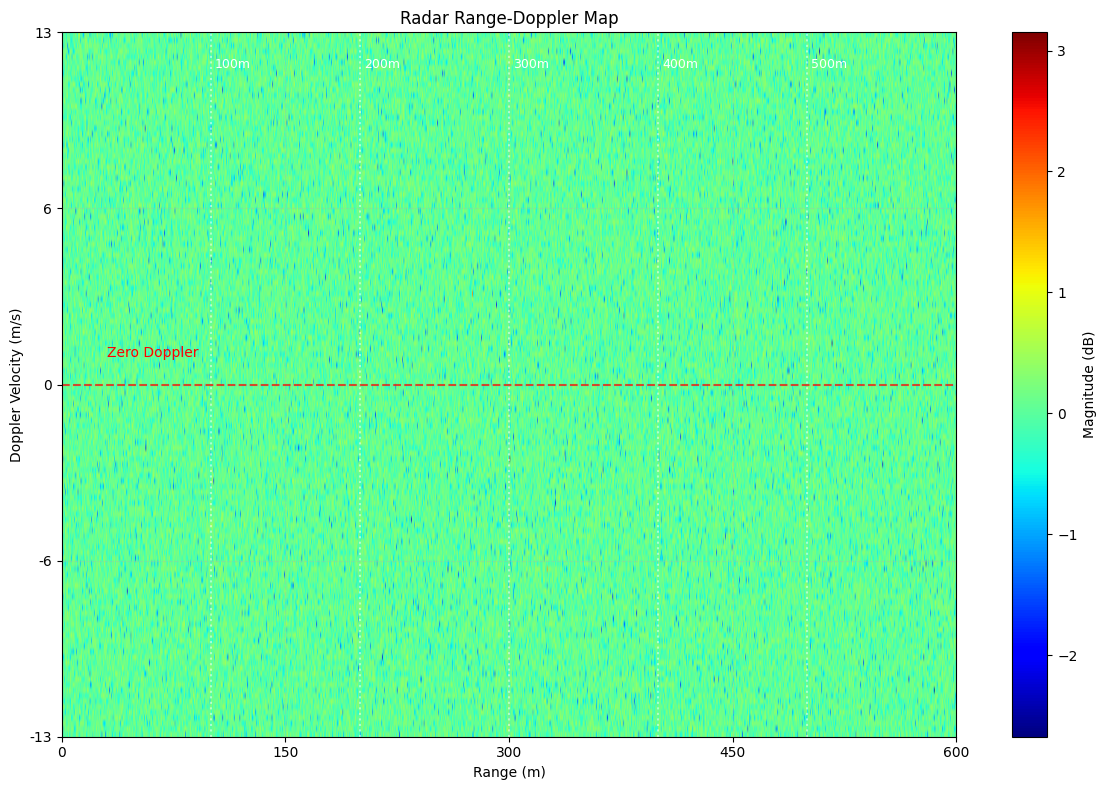

In [9]:
# 生成示例RD图数据 (1200多普勒单元 × 128距离单元)
# 注意：现在形状为(1200, 128)
rd_map = np.random.randn(128,1200) + 1j * np.random.randn(128, 1200)
print("RD图数据形状:", rd_map.shape)
# 添加一些目标信号
rd_map[50, 600] = 1000 + 1000j  # 强目标在600多普勒单元，50距离单元
rd_map[80, 550] = 50 + 50j    # 中等目标
rd_map[30, 650] = 30 + 30j    # 弱目标

# 假设雷达参数
range_resolution = 0.5  # 米/距离单元
doppler_resolution = 0.2  # 米/秒/多普勒单元

# 绘制RD图
fig = plot_range_doppler(
    rd_map,
    range_res=range_resolution,
    doppler_res=doppler_resolution,
    title="Radar Range-Doppler Map",
    cmap="jet"
)

# 保存图像
fig.savefig("range_doppler_map.png", dpi=300)

# 显示图像
plt.show()